# Make Figures for Paper

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import rawmovie
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import pickle
import src.utils.preprocess as preprocess
# import src.utils.sigmoid as sigmoid
from scipy.io import savemat, loadmat
from scipy.signal import convolve2d
import re
import visionloader as vl
import sta_utils as su
from scipy.spatial import ConvexHull
import src.utils.cellmap as cellmap
import src.utils.encoding_decoding_simulation_pooled as edsp
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Ellipse
from PIL import Image
import multiprocessing
from multiprocessing import Pool
import warnings
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.animation as animation
from IPython.core.display import HTML

import sys
sys.path.append('/Volumes/Lab/Users/ajphillips/greedy/src/')
import sigmoid

from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process
from elephant.spike_train_dissimilarity import victor_purpura_distance
from neo.core import SpikeTrain

In [240]:
piece = '2024-09-25-3'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
pp_base = analysis_base
gsort_base = analysis_base
vstim_base = analysis_base
espont_base = analysis_base
pickle_path_base = "gsort_single_v2"
label = ""
wnoise = "data003"

wnoise_path = os.path.join(analysis_base, wnoise)
spike_path = os.path.join(analysis_base, f"spikes{label}")
cell_types = ['ON parasol', 'OFF parasol']

In [241]:
wn1 = 'data003'
estim1 = 'data004'
wn2 = 'data003'
estim2 = 'data009'

gsort_se_path = os.path.join(gsort_base, "gsort", estim1)

In [242]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]
with np.load(os.path.join(dict_path,f"{wnoise}_bundle_thresholds.npz")) as data:
    bundle = data["bundle_thresholds"]

amplitudes = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
        1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
        2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
        3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

bundle_thresholds = amplitudes[bundle[:512,1].astype(int)-1] # subtract 1 to get the last amplitude index with no bundle activity
bundle_thresholds[bundle[:512,1].astype(int) == -1] = amplitudes[-1] # if no detected bundle activity, set to max amplitude

print(selective_stimuli.shape)
print(bundle_thresholds.shape)

np.set_printoptions(suppress=True)
print(selective_stimuli)

(301, 4)
(512,)
[[   2.         7597.            3.57597269    1.        ]
 [   3.           62.            3.21697526    1.        ]
 [   5.           62.            2.39757895    1.        ]
 ...
 [ 515.           62.            2.72291755    1.        ]
 [ 516.         7713.            3.2508206     1.        ]
 [ 517.           62.            3.66670644    1.        ]]


In [243]:
vcd = vl.load_vision_data(wnoise_path,wn1,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)

print(f"Total selective cells of type {cell_types}: {selective_cells_of_interest.size}")

mask = np.isin(selective_cells_of_interest, [6017,2086,62,1877,7098])
mask = np.logical_not(mask)
selective_cells_of_interest = selective_cells_of_interest[mask]

print(f"Total selective cells of type {cell_types} excluding bad edge cells: {selective_cells_of_interest.size}")

# Find ON parasol and OFF parasol cell IDs
on_parasol_cells = np.array([c for c in selective_cells_of_interest if c in vcd.get_all_cells_similar_to_type('ON parasol')])
off_parasol_cells = np.array([c for c in selective_cells_of_interest if c in vcd.get_all_cells_similar_to_type('OFF parasol')])

Total selective cells of type ['ON parasol', 'OFF parasol']: 45
Total selective cells of type ['ON parasol', 'OFF parasol'] excluding bad edge cells: 40


## Figure 1A: ON and OFF RFs

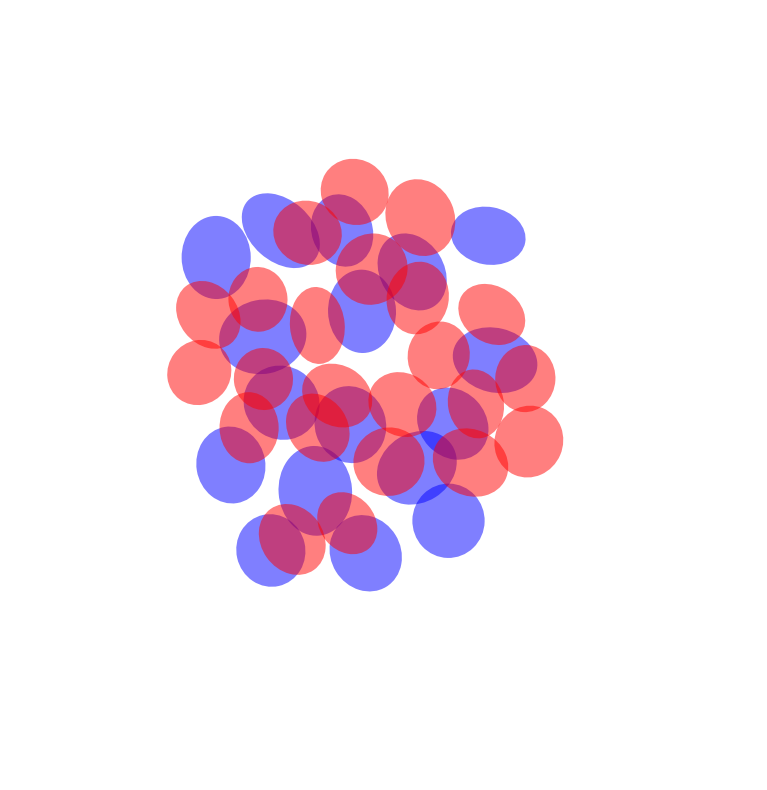

In [244]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))

assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

for c in np.concatenate((on_parasol_cells, off_parasol_cells)):

    center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
    # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
    center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
    std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
    std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
    rot = vcd.get_stafit_for_cell(c).rot

    rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

    if c in on_parasol_cells:
        # rf.set_edgecolor('red')
        rf.set_fill(True)
        rf.set_facecolor('blue')
        rf.set_alpha(0.5)
    elif c in off_parasol_cells:
        # rf.set_edgecolor('blue')        
        rf.set_fill(True)
        rf.set_facecolor('red')
        rf.set_alpha(0.5)
    
    ax.add_patch(rf)

ax.set_xlim(0+250, 640-1-225)
ax.set_ylim(0+100, 320-1-50)
# ax.set_xlim(0+250, 640-1-200)
# ax.set_ylim(0+75, 320-1-50)
# ax.set_xlim(0+225, 640-1-225)
# ax.set_ylim(0+75, 320-1-75)
ax.set_aspect('equal')
# ax.set_title(cell_type)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

In [7]:
import itertools

# Initialize variables to store the closest cell IDs and their RF distances
closest_on_parasol_cell = None
closest_off_parasol_cell = None
closest_rf_distance = float('inf')

# Iterate over all combinations of ON parasol and OFF parasol cells
for on_cell_id, off_cell_id in itertools.product(on_parasol_cells, off_parasol_cells):
    # Get the RFs for the ON parasol and OFF parasol cells
    on_rf = vcd.get_stafit_for_cell(on_cell_id)
    off_rf = vcd.get_stafit_for_cell(off_cell_id)

    # Calculate the distance between the RFs
    rf_distance = np.sqrt((on_rf.center_x - off_rf.center_x)**2 + (on_rf.center_y - off_rf.center_y)**2)

    # Check if the distance is smaller than the current closest distance
    if rf_distance < closest_rf_distance:
        # if on_cell_id in [2611,7163] or off_cell_id in [2749,6856]: # For 2024-09-10-12
        #     continue
        if on_cell_id in [1877,5929,7098,7713,2091,3618,7597,6331] or off_cell_id in [1697,6017,7247,62,2086,3381,333,6857]: # For 2024-09-25-3
            continue
        closest_on_parasol_cell = on_cell_id
        closest_off_parasol_cell = off_cell_id
        closest_rf_distance = rf_distance

# Print the closest ON parasol and OFF parasol cell IDs
print("Closest ON parasol cell ID:", closest_on_parasol_cell)
print("Closest OFF parasol cell ID:", closest_off_parasol_cell)

Closest ON parasol cell ID: 2270
Closest OFF parasol cell ID: 2404


## Figure 1A: Select ON and OFF RFs

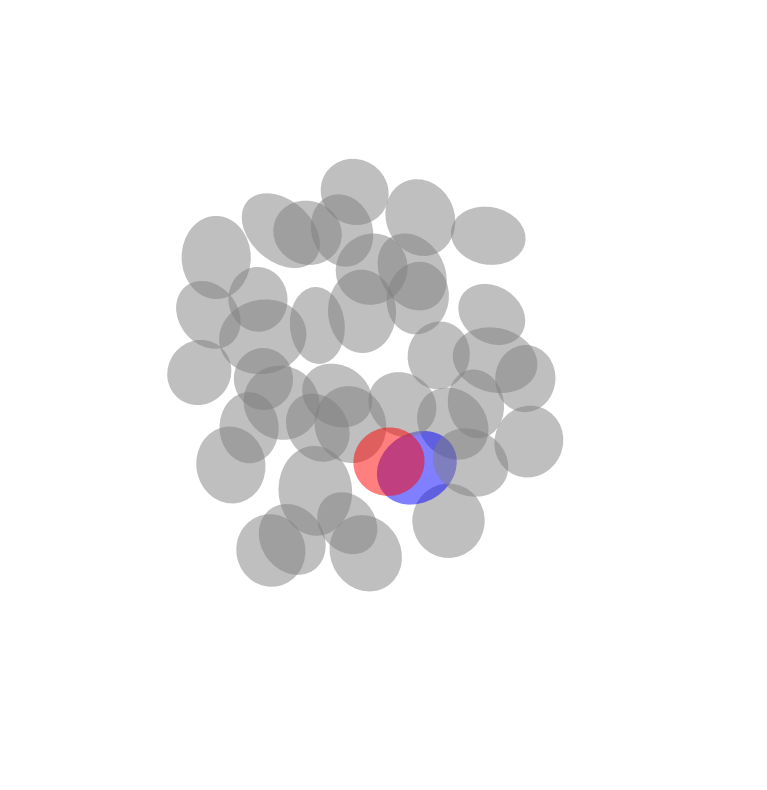

In [8]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))

window_buffer = 200
window_size = 150

assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

for c in np.concatenate((on_parasol_cells, off_parasol_cells)):

    center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
    # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
    center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
    std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
    std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
    rot = vcd.get_stafit_for_cell(c).rot

    rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

    if c == closest_on_parasol_cell:
        # rf.set_edgecolor('red')
        rf.set_fill(True)
        rf.set_facecolor('blue')
        rf.set_alpha(0.5)
    elif c == closest_off_parasol_cell:
        # rf.set_edgecolor('blue')
        rf.set_fill(True)
        rf.set_facecolor('red')
        rf.set_alpha(0.5)
    else:
        # rf.set_edgecolor('gray')
        rf.set_fill(True)
        rf.set_facecolor('gray')
        rf.set_alpha(0.5)
    
    # Skip adding patch if RF center is farther than threshold from closest_on_parasol_cell RF center
    if np.sqrt((center_x - STIXEL * vcd.get_stafit_for_cell(closest_on_parasol_cell).center_x)**2 + 
               (center_y - STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(closest_on_parasol_cell).center_y))**2) > window_buffer:
        continue
    ax.add_patch(rf)

# Adjust axis limits to only show the region of the cells plotted, according to the distance threshold from closest_on_parasol_cell
# ax.set_xlim(STIXEL * vcd.get_stafit_for_cell(closest_on_parasol_cell).center_x - window_size, STIXEL * vcd.get_stafit_for_cell(closest_on_parasol_cell).center_x + window_size)
# ax.set_ylim(STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(closest_on_parasol_cell).center_y) - window_size, 
#             STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(closest_on_parasol_cell).center_y) + window_size)

ax.set_xlim(0+250, 640-1-225)
ax.set_ylim(0+100, 320-1-50)
# ax.set_xlim(0+250, 640-1-200)
# ax.set_ylim(0+75, 320-1-50)
# ax.set_xlim(0+225, 640-1-225)
# ax.set_ylim(0+75, 320-1-75)
ax.set_aspect('equal')
# ax.set_title(cell_type)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

## Figure 1A: Select ON and OFF EIs

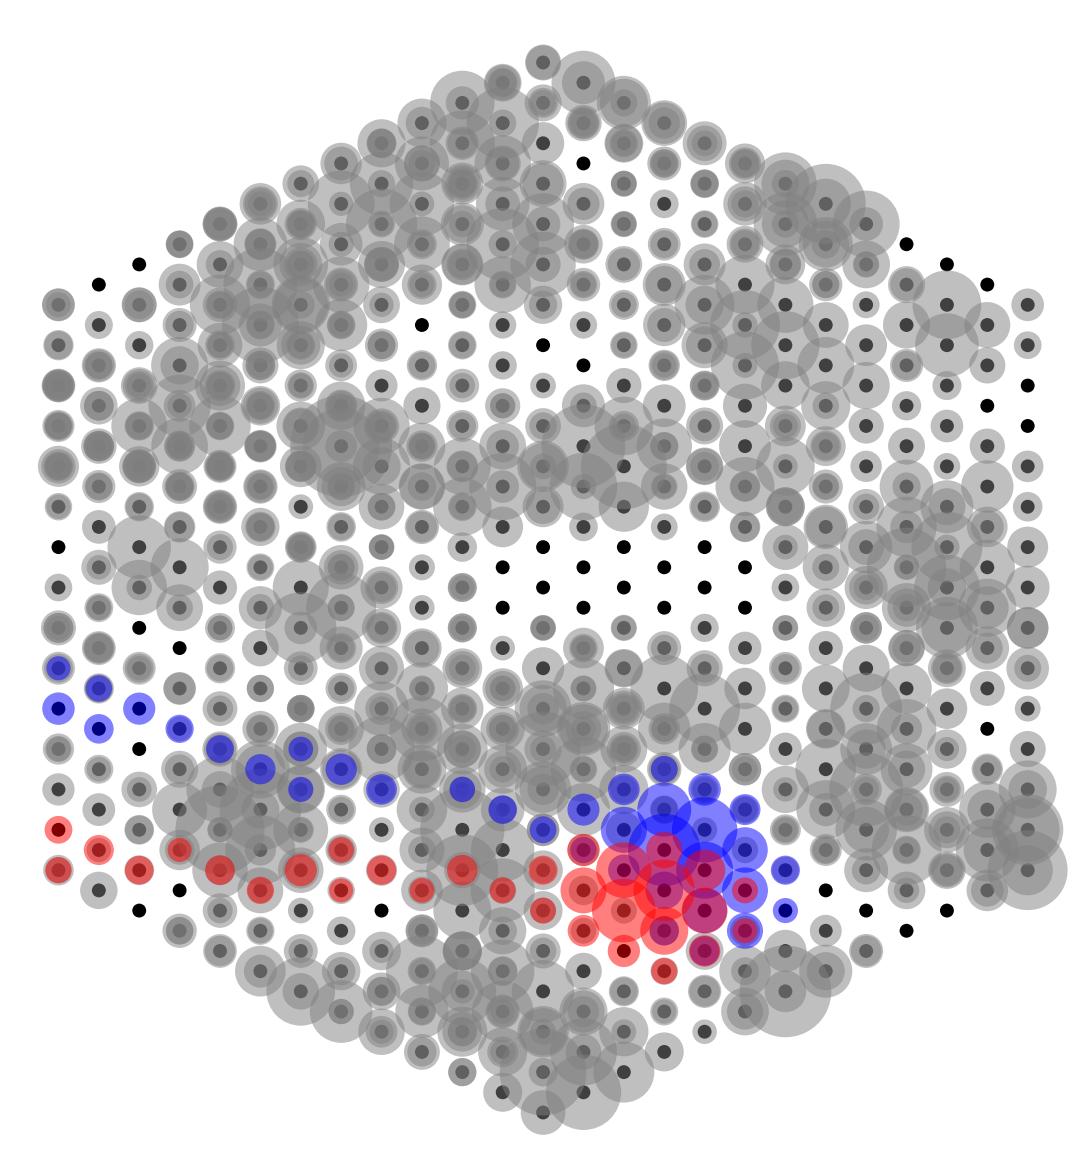

In [87]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(15,15))

# Plot electrodes
coords = vcd.get_electrode_map()
ax.scatter(coords[:,0], coords[:,1], facecolors='k', edgecolors='none', s=100)

for cell_id in selective_cells_of_interest:
    if cell_id in [closest_on_parasol_cell, closest_off_parasol_cell]:
        continue

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -10
    good_inds = np.argwhere(ei < thresh).flatten()

    # Plot EI
    ei_size_factor = -30
    ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='gray', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
    # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
    ax.axes.set_aspect('equal')
    

for cell_id in [closest_on_parasol_cell, closest_off_parasol_cell]:

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -10
    good_inds = np.argwhere(ei < thresh).flatten()

    # Plot EI
    ei_size_factor = -30
    if cell_id == closest_on_parasol_cell:
        ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='blue', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)
    elif cell_id == closest_off_parasol_cell:
        ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='red', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
    # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
    ax.axes.set_aspect('equal')

ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

## Figure 1B: Activating electrodes & selective electrodes for select ON and OFF

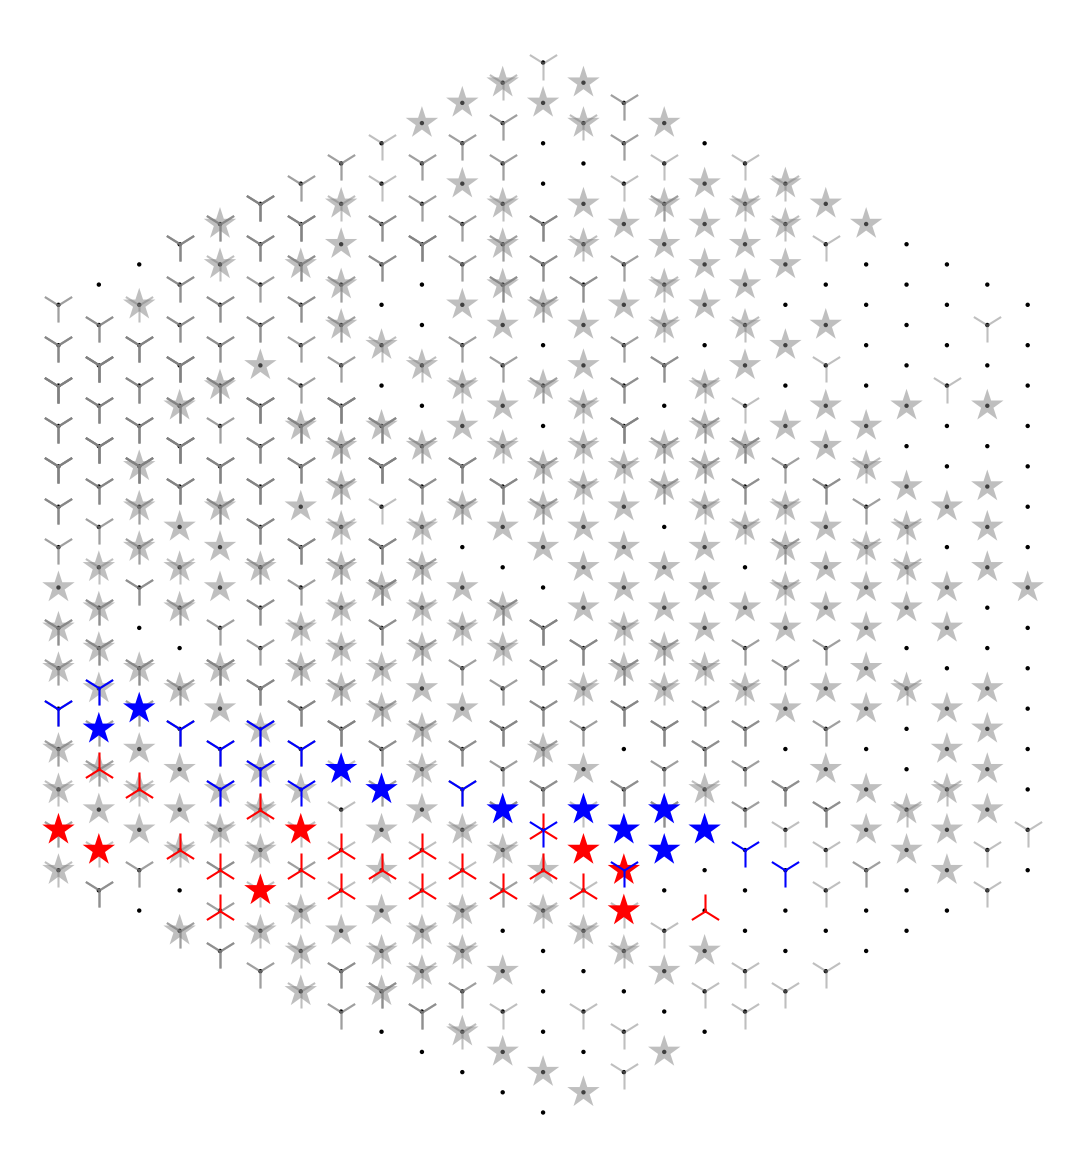

In [10]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(15,15))

# Plot electrodes
coords = vcd.get_electrode_map()
ax.scatter(coords[:,0], coords[:,1], facecolors='k', edgecolors='none', s=10)

for cell_id in selective_cells_of_interest:
    if cell_id in [closest_on_parasol_cell, closest_off_parasol_cell]:
        continue

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -10
    good_inds = np.argwhere(ei < thresh).flatten()

    # Plot EI
    # ei_size_factor = -5
    # if cell_id == closest_on_parasol_cell:
    #     ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='gray', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)
    # elif cell_id == closest_off_parasol_cell:
    #     ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='k', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
    # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
    ax.axes.set_aspect('equal')

    # Identify from selective_stimuli which electrodes are selective for cell_id, and get the corresponding amp
    selective_subset = selective_stimuli[selective_stimuli[:,1] == cell_id]
    selective_electrodes = selective_subset[:,0].astype(int)
    selective_amps = selective_subset[:,2]

    # Label electrodes
    for elec in np.arange(1,520):
        if elec in selective_electrodes:
            continue
        try:
            amps, probs, slp, thr, std, success = sigmoid.compute_sigmoid(gsort_se_path, pickle_path_base, cell_id, f"p{elec}", plot=False)
            if np.isnan(thr):
                continue
            ax.scatter(coords[elec-1,0],coords[elec-1,1], facecolors='gray', s=600, alpha=0.5, marker='1')
        except:
            continue

    # Label electrodes
    for z,elec in enumerate(selective_electrodes):
        ax.scatter(coords[elec-1,0],coords[elec-1,1], facecolors='gray', edgecolors='none', s=600, alpha=0.5, marker='*')

for cell_id in [closest_off_parasol_cell, closest_on_parasol_cell]:

    # Extract EI for desired cell
    cell_ei = vcd.get_ei_for_cell(cell_id).ei

    # Find negative peak for each recording electrode
    ei = np.amin(cell_ei,axis=1)
    thresh = -10
    good_inds = np.argwhere(ei < thresh).flatten()

    # Plot EI
    # ei_size_factor = -5
    # if cell_id == closest_on_parasol_cell:
    #     ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='gray', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)
    # elif cell_id == closest_off_parasol_cell:
    #     ax.scatter(coords[good_inds,0], coords[good_inds,1], facecolors='k', edgecolors='none', s=ei[good_inds]*ei_size_factor, alpha=0.5)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
    # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
    ax.axes.set_aspect('equal')

    # Identify from selective_stimuli which electrodes are selective for cell_id, and get the corresponding amp
    selective_subset = selective_stimuli[selective_stimuli[:,1] == cell_id]
    selective_electrodes = selective_subset[:,0].astype(int)
    selective_amps = selective_subset[:,2]

    # Label electrodes
    for elec in np.arange(1,520):
        if elec in selective_electrodes:
            continue
        try:
            amps, probs, slp, thr, std, success = sigmoid.compute_sigmoid(gsort_se_path, pickle_path_base, cell_id, f"p{elec}", plot=False)
            if np.isnan(thr):
                continue
            if cell_id == closest_on_parasol_cell:
                ax.scatter(coords[elec-1,0],coords[elec-1,1], facecolors='blue', s=600, alpha=1, marker='1')
            elif cell_id == closest_off_parasol_cell:
                ax.scatter(coords[elec-1,0],coords[elec-1,1], facecolors='red', s=600, alpha=1, marker='2')
        except:
            continue

    # Label electrodes
    for z,elec in enumerate(selective_electrodes):
        if cell_id == closest_on_parasol_cell:
            ax.scatter(coords[elec-1,0],coords[elec-1,1], facecolors='blue', edgecolors='none', s=600, alpha=1, marker='*')
        elif cell_id == closest_off_parasol_cell:
            ax.scatter(coords[elec-1,0],coords[elec-1,1], facecolors='red', edgecolors='none', s=600, alpha=1, marker='*')
        
# Make legend
# legend_elements = [Line2D([], [], marker='1', color='red', linestyle='None', label='ON activating', markersize=20),
#                    Line2D([], [], marker='*', color='red', linestyle='None', label='ON selective', markersize=20),
#                    Line2D([], [], marker='2', color='blue', linestyle='None', label='OFF activating', markersize=20),
#                    Line2D([], [], marker='*', color='blue', linestyle='None', label='OFF selective', markersize=20)]
# ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.8, 1), fontsize=20)

ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

## Figure 1B: Insets for interesting electrodes
Use *electrical_stim_selectivity.ipynb*
## Figure 1C: Spike train example for select ON and OFF

In [246]:
# Load response indices
spike_trains = np.load(f"{analysis_base}/dictionary/spike_trains{label}.npz", allow_pickle=True)
response_indices = spike_trains['response_indices']
for i in range(len(response_indices)):
    print(f"Response {i}: {response_indices[i]}")

Response 0: 14
Response 1: 1330
Response 2: 531
Response 3: 1032
Response 4: 1333
Response 5: 1334
Response 6: 635
Response 7: 436
Response 8: 737
Response 9: 338
Response 10: 239
Response 11: 1240
Response 12: 41
Response 13: 542
Response 14: 943
Response 15: 744
Response 16: 1145
Response 17: 1346
Response 18: 947
Response 19: 1048
Response 20: 249
Response 21: 1350
Response 22: 651
Response 23: 1152
Response 24: 553
Response 25: 654
Response 26: 1255
Response 27: 56
Response 28: 357
Response 29: 158
Response 30: 1059
Response 31: 860
Response 32: 761
Response 33: 562
Response 34: 463
Response 35: 1164
Response 36: 265
Response 37: 1166
Response 38: 1267
Response 39: 1368
Response 40: 869
Response 41: 1070
Response 42: 471
Response 43: 1172
Response 44: 973
Response 45: 974
Response 46: 1075
Response 47: 176
Response 48: 577
Response 49: 878
Response 50: 479
Response 51: 780
Response 52: 1281
Response 53: 1282
Response 54: 383
Response 55: 784
Response 56: 1385
Response 57: 1286
Resp

In [12]:
def flip(cell, pattern, amp, flip_prob=0.9, plot=False):

    gsort_path_base1 = os.path.join(gsort_base, "gsort", estim1)
    gsort_path_base2 = os.path.join(gsort_base, "gsort", estim2)

    patterns = sigmoid.find_activating_patterns(gsort_path_base1, cell)
    patterns = np.sort(patterns)
    pattern_nos = [int(p.split('p')[-1]) for p in patterns]
    
    if pattern not in pattern_nos:
        raise Exception("Pattern not found in gsort_path_base1")

    pattern = f"p{pattern}"

    try:
        if plot:
            fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

        amps1, probs1, slp1, thr1, std1, success1 = sigmoid.compute_sigmoid(gsort_path_base1, pickle_path_base, cell, pattern, plot=False)
        
        if plot:
            sigmoid.plot_sigmoid(ax, amps1, probs1, slp1, thr1, 'k')

        try:
            amps2, probs2, slp2, thr2, std2, success2 = sigmoid.compute_sigmoid(gsort_path_base2, pickle_path_base, cell, pattern) # mapping['forward'][cell]

            if plot:
                sigmoid.plot_sigmoid(ax, amps2, probs2, slp2, thr2, 'b')

        except Exception as e:
            if plot:
                ax.text(0.1,0.9,str(e))
            else:
                raise e

    except Exception as ex:
        if plot:
            ax.text(0.1,0.1,str(ex))
        else:
            raise ex
    
    if plot:
        ax.set_xlim(0,4)
        ax.set_ylim(0,1)
        ax.set_xlabel('Stimulation Amplitude (uA)')
        ax.set_ylabel('Activation Probability')
        ax.set_title(f"{piece} cell {cell} electrode {pattern[1:]}")
        plt.show()

    # Perform disambiguation
    # print(f"calibration prob {probs1[amp-1]}, bookend prob {probs2[amp-1]}, flipping {probs2[amp-1] > flip_prob}")
    if probs2[amp-1] > flip_prob:
        return True
    else:
        return False
    
def amps_to_indices(amps):
    AMPS = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
        1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
        2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
        3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])
    return np.array([np.argmin(np.abs(AMPS - amp)) + 1 for amp in amps]) # 1-indexed

def boolean_spikes(gsort_path_base, pickle_path_base, cell, pattern, k):
    # Set the random number seed for reproducibility of edge case behavior
    np.random.seed(cell+int(pattern[1:]))

    gsort_path = f"{gsort_path_base}/{pattern}/"
   
    pickle_path = f"{pickle_path_base}_n{cell}_{pattern}_k{k}.pkl"
    with open(gsort_path + pickle_path, 'rb') as f:
        prob_dict = pickle.load(f)
        
        cosine_prob, prob, initial_clustering_with_virtual, final_clustering, graph_info = prob_dict['cosine_prob'], prob_dict['prob'], prob_dict['initial_clustering_with_virtual'], prob_dict['final_clustering'], prob_dict['graph_info']

        cosine_prob = cosine_prob[0]
        graph_info = graph_info[2]
        final_clustering = final_clustering[0]

        # print(cosine_prob)
        # print(prob)
        # print(graph_info)
        # print(initial_clustering_with_virtual)

        if np.isclose(cosine_prob, 0, rtol=0, atol=1e-5):
            bool_spikes = [False for _ in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes

        # get index of dictionary entry with the value cell
        edges = [*graph_info]
        edge = get_key(graph_info, cell)
        # print(edge)
        # print(edges)
        path = []
        for e in edge:
            path.extend(get_path(edges, edges.index(e)))

        # print(path)

        if np.isclose(cosine_prob, prob, rtol=0, atol=1e-5):
            bool_spikes = [spike in path for spike in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        

        all_possible_edges = []
        difference = np.round(np.abs(cosine_prob - prob)*len(initial_clustering_with_virtual)).astype(int)
        # print(difference)

        for e in edge:
            _ = find_cosine_path(edges, edges.index(e), initial_clustering_with_virtual, all_possible_edges, difference)
        # print(all_possible_edges)

        if len(all_possible_edges) > 1:
            warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one
        elif len(all_possible_edges) == 0:
            warnings.warn("No valid cosine similarity single path removal") # indicating multiple edges have been removed, randomly assign the spikes
            
            # Build a randomly shuffled list of booleans corresponding to the cosine probability
            bool_spikes = [True if i < np.round(cosine_prob*len(initial_clustering_with_virtual)).astype(int) else False for i in range(len(initial_clustering_with_virtual))]
            np.random.shuffle(bool_spikes)

            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        
        removal_path = get_path(edges, edges.index(all_possible_edges[0]))
        # print(removal_path)

        bool_spikes = [spike in path and spike not in removal_path for spike in initial_clustering_with_virtual]
        # print(bool_spikes)
        # print(sum(bool_spikes)/len(bool_spikes))
        
        return bool_spikes


def get_key(my_dict, val):
    keys = []
   
    for key, value in my_dict.items():
        if val == value:
            keys.append(key)

    if len(keys) == 0:
        raise ValueError("Cell not assigned to any edge")

    return keys

def get_path(edges, start_index):
    path = []
    path.append(edges[start_index][1])

    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            path.extend(get_path(edges, i))

    return path
    
def find_cosine_path(edges, start_index, initial_clustering_with_virtual, all_possible_edges, difference):

    count = 0
    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            count += find_cosine_path(edges, i, initial_clustering_with_virtual, all_possible_edges, difference)
    
    total = np.sum(edges[start_index][1] == initial_clustering_with_virtual) + count
    if total == difference:
        all_possible_edges.append(edges[start_index])
    return total

def transform_to_519(electrode):
    skip_elecs = np.array([1, 130, 259, 260, 389, 390, 519])
    elecs = np.arange(1, 520)
    elecs = elecs[~np.isin(elecs, skip_elecs)]
    return elecs[electrode-1]


In [13]:
espont = "data007_from_data003"
vstim = "data005_from_data003"

vstim_path = os.path.join(vstim_base, vstim)
espont_path = os.path.join(espont_base, espont)

In [14]:
vstim_vcd = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)
print(f"Total selective cells of type {cell_types}: {selective_cells_of_interest.size}")

spike_times = np.array([vstim_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object) / 20 # convert to ms

ttl_times = vstim_vcd.ttl_times / 20 # convert to ms

responses = []
for j in range(len(ttl_times)-1):
    if j == 1529: # CHANGE ME
        low = ttl_times[j]
        high = ttl_times[j] + 500
        filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
        responses.append(filtered_spike_times)
    else:
        low = ttl_times[j]
        high = ttl_times[j+1]
        filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
        responses.append(filtered_spike_times)
low = ttl_times[-1]
high = ttl_times[-1] + 500
filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
responses.append(filtered_spike_times)

Total selective cells of type ['ON parasol', 'OFF parasol']: 45


  0%|          | 0/58 [00:00<?, ?it/s]

100%|██████████| 58/58 [00:42<00:00,  1.36it/s]


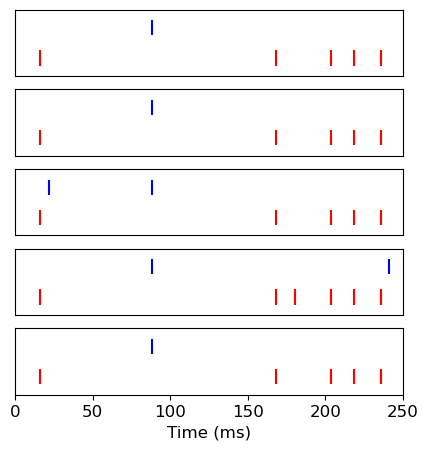

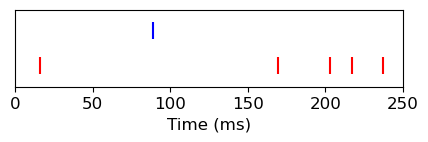

In [15]:
estim_trial = 0

for frame_no, response_no in enumerate(response_indices):

    if frame_no != 51: # 51 both # 97 off # 91 on
        continue

    estim = f"data007/frame_{frame_no}"
    pp_path = os.path.join(pp_base, estim)
    gsort_path = os.path.join(gsort_base, "gsort", estim, wnoise)
    
    path = os.path.join(analysis_base, "estim")

    # Read in .mat file
    ppinfo = loadmat(os.path.join(path,f"preprocessing_info{label}.mat"))
    experiment_boundaries, experiment_names = ppinfo["experimentBoundaries"], ppinfo["experimentNames"]
    # print(f"Experiment boundaries shape {experiment_boundaries.shape}")

    with open(os.path.join(path,f"spike_trains{label}.sef"), "rb") as f:
        sef = np.fromfile(f, dtype=np.int32)
        sef = np.reshape(sef, (int(len(sef)/3), 3), order='F')

    sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

    unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
    unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True) 


    spikes = {}
    probabilities = {}

    initial_spikes = {}
    initial_probabilities = {}


    for t in tqdm(range(unique_times.shape[0])):

        # Set up nested dictionaries
        initial_spikes[t] = {}
        initial_probabilities[t] = {}
        spikes[t] = {}
        probabilities[t] = {}

        # Identify all electrical stimuli delivered simultaneously at time t
        stim = sef_of_interest[np.where(sef_of_interest[:,0] == unique_times[t])[0],1:]

        for s in stim:

            # Find the row of selective_stimuli corresponding to each electrical stimulus
            selective_stimulus = selective_stimuli[np.where((selective_stimuli[:,0] == transform_to_519(s[0])) & (amps_to_indices(selective_stimuli[:,2]) == s[1]))[0][0]]

            # Look for electrical spike sorting results at the time-pattern for each targeted cell (only ever one movie per time-pattern)
            c = int(selective_stimulus[1])

            bs = boolean_spikes(gsort_path, pickle_path_base, c, f"p{t+1}", 0)

            initial_spikes[t][c] = bs
            initial_probabilities[t][c] = np.mean(bs)

            if int(selective_stimulus[3]) and (np.mean(bs) < 0.1): 
                if flip(c, transform_to_519(s[0]), s[1], flip_prob=0.8, plot=False): 
                    bs = [not b for b in bs]

            spikes[t][c] = bs
            probabilities[t][c] = np.mean(bs)


    # Make sure this index agrees with the frame you are looking at
    response = responses[response_no]

    # Align response rasters in time (the very first attempted estim is aligned with the very first rounded recorded vstim spike)
    bin_size_ms = 2.5
    rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

    response_reference_candidates = []
    for c in range(len(rounded_response)):
        if len(rounded_response[c]) > 0:
            response_reference_candidates.append(rounded_response[c][0])
    response_reference = np.min(response_reference_candidates)

    # Make mask for the closest on and off parasol cells in the selective_cells_of_interest array
    mask = np.isin(selective_cells_of_interest, [closest_on_parasol_cell, closest_off_parasol_cell])
    
    # Flip the response and mask to put ON parasol on top of spike raster plot
    response = np.flip(response, axis=0)
    mask = np.flip(mask)

    fig, ax = plt.subplots(5, 1, sharex=False, sharey=True, figsize=(5,5))

    for et, estim_trial in enumerate([1,6,7,9,11]): # range(5)

        sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

        unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
        unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True) 


        # Build electrically evoked response for a single trial using the spike dictionary
        estim_response = [[] for _ in range(len(selective_cells_of_interest))]

        for t in range(unique_times.shape[0]):
            for c in spikes[t]:
                if spikes[t][c][estim_trial]:
                    estim_response[np.where(selective_cells_of_interest == c)[0][0]].append(unique_times[t])

        for c in range(len(estim_response)):
            estim_response[c] = np.array(estim_response[c])
        estim_response = np.array(estim_response, dtype=object) / 20 # convert to ms


        # if response[0].size == 0 or response[1].size == 0:
        #     continue
        # print(f"Frame {frame_no} has {response[0].size} and {response[1].size} spikes")


        estim_response_reference = sef_of_interest[0,0] / 20 # convert to ms

        global_reference = response_reference - ttl_times[response_no]


        espont_vcd = vl.load_vision_data(espont_path,espont,
                                        include_neurons=True)

        espont_spike_times = np.array([espont_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object)

        offset = 20000 # offset of 20000 samples between SEF times and actual data
        low = unique_times[0] + offset
        high = unique_times[-1] + offset
        total_response = np.array([(spike_time[(low < spike_time) & (spike_time < high)] - offset) / 20 for spike_time in espont_spike_times], dtype=object) # convert to ms


        # Get rid of any electrically evoked spikes identified by Vision
        espont_response = [[] for _ in range(len(total_response))]
        for c in range(len(total_response)):
            espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - unique_times/20) >= -1) & ((spike - unique_times/20) <= 2))])
        espont_response = np.array(espont_response, dtype=object)

        # Flip the order of the estim and espont responses to put ON parasol on top of spike raster plot
        estim_response = np.flip(estim_response, axis=0)
        espont_response = np.flip(espont_response, axis=0)

        # Create a spike raster plot
        ax[et].eventplot(estim_response[mask]-estim_response_reference+global_reference, linelengths=0.5, colors=['red', 'blue'])
        ax[et].eventplot(espont_response[mask]-estim_response_reference+global_reference, linelengths=0.5, colors=['red', 'blue'])

        # Set the y-axis ticks and labels
        ax[et].set_yticks(range(2), ['OFF parasol', 'ON parasol'], fontsize=12)

        # Restrict the x axis
        ax[et].set_xlim(0, 250)

        # Make all ticks larger
        plt.tick_params(axis='both', which='major', labelsize=12)

        # Hide y-axis labels for all plots
        ax[et].tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

        # Hide x-axis labels for all but the bottom plot
        if et != 4:
            ax[et].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Set the x-axis label
    ax[et].set_xlabel('Time (ms)', fontsize=12)

    # Show the plot
    plt.show()


    plt.figure(figsize=(5, 1))

    # Create a spike raster plot
    plt.eventplot(response[mask]-response_reference+global_reference, linelengths=0.5, colors=['red', 'blue'])

    # Set the y-axis ticks and labels
    plt.yticks(range(2), ['OFF parasol', 'ON parasol'], fontsize=12)
    # plt.ylabel('Neuron')

    # Set the x-axis label
    plt.xlabel('Time (ms)', fontsize=12)

    # Set the plot title
    # plt.title('Visually Evoked Spike Trains')

    # Restrict the x axis
    plt.xlim(0, 250)

    # Make all ticks larger
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Hide y-axis labels
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    # Show the plot
    plt.show()

## Figure 2A/D: Natural scene with ON and OFF RFs

In [16]:
imagenet = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/INbrownian/INbrownian_05s_test_045.rawMovie")
imagenet_frames, _ = imagenet.get_all_frames() # All color channels are the same

In [17]:
# Super sample the frames to match the size of the VCD frames
imagenet_frames = np.repeat(imagenet_frames, 2, axis=1)
imagenet_frames = np.repeat(imagenet_frames, 2, axis=2)

print(imagenet_frames.shape)

(9000, 320, 640, 3)


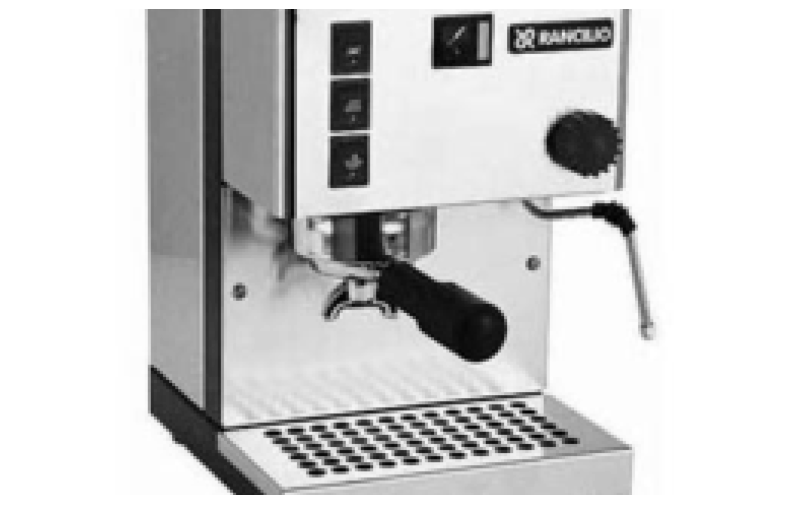

In [260]:
natural_scene = 34

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot natural scene
ax.imshow(imagenet_frames[natural_scene*60,:,:,0], cmap='gray')

# Plot RFs
assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

for c in np.concatenate((on_parasol_cells, off_parasol_cells)):

    center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
    # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
    center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
    std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
    std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
    rot = vcd.get_stafit_for_cell(c).rot

    rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

    if c in on_parasol_cells:
        # rf.set_edgecolor('red')
        rf.set_fill(True)
        rf.set_facecolor('blue')
        rf.set_alpha(0.5)
    elif c in off_parasol_cells:
        # rf.set_edgecolor('blue')        
        rf.set_fill(True)
        rf.set_facecolor('red')
        rf.set_alpha(0.5)
    
    # ax.add_patch(rf)

ax.set_xlim(0+65, 640-1-65)
ax.set_ylim(0, 320-1)
ax.set_aspect('equal')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

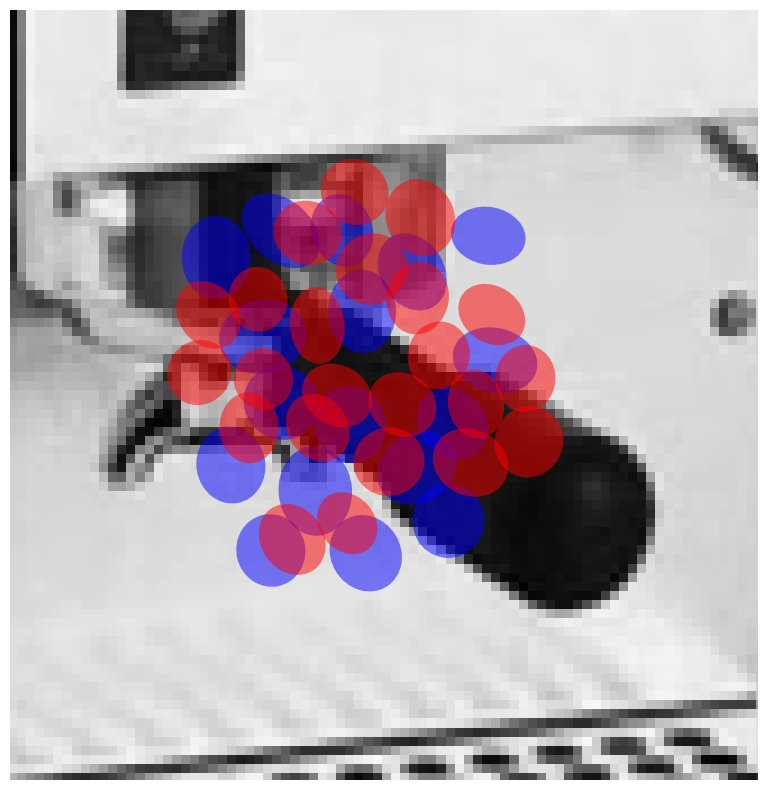

In [261]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot natural scene
ax.imshow(imagenet_frames[natural_scene*60,:,:,0], cmap='gray')

# Plot RFs
assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

for c in np.concatenate((on_parasol_cells, off_parasol_cells)):

    center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
    # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
    center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
    std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
    std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
    rot = vcd.get_stafit_for_cell(c).rot

    rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

    if c in on_parasol_cells:
        # rf.set_edgecolor('red')
        rf.set_fill(True)
        rf.set_facecolor('blue')
        rf.set_alpha(0.5)
    elif c in off_parasol_cells:
        # rf.set_edgecolor('blue')        
        rf.set_fill(True)
        rf.set_facecolor('red')
        rf.set_alpha(0.5)
    
    ax.add_patch(rf)

ax.set_xlim(0+250, 640-1-225)
ax.set_ylim(0+100, 320-1-50)
# ax.set_xlim(0+250, 640-1-200)
# ax.set_ylim(0+75, 320-1-50)
# ax.set_xlim(0+225, 640-1-225)
# ax.set_ylim(0+75, 320-1-75)
ax.set_aspect('equal')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

## Figure 2B: Generating an optimized electrical stimulation sequence
Use *stimulus_assigner.ipynb*
## Figure 2C/D: Electrical response spike rasters for ON and OFFs

100%|██████████| 89/89 [01:56<00:00,  1.31s/it]


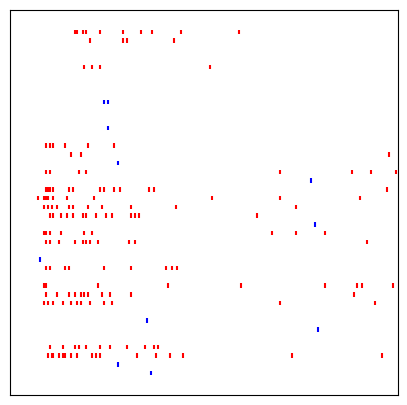

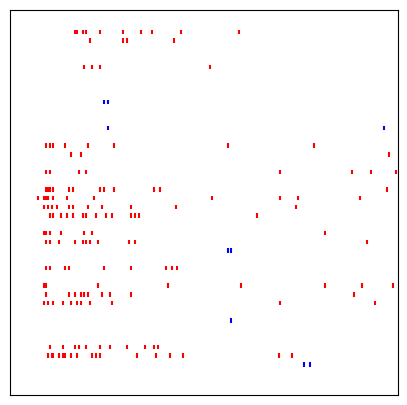

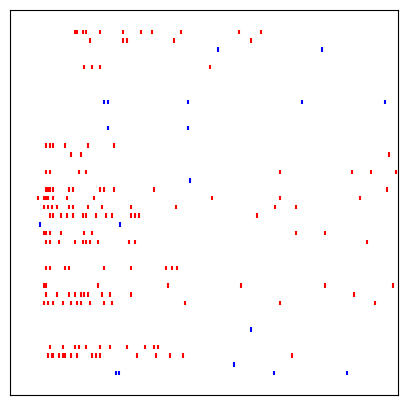

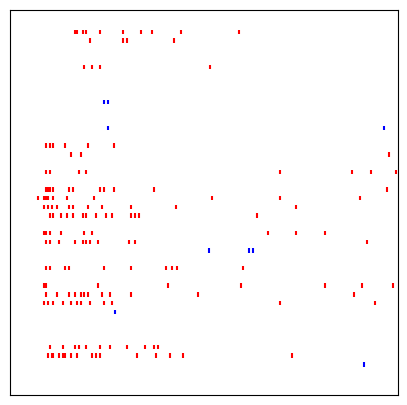

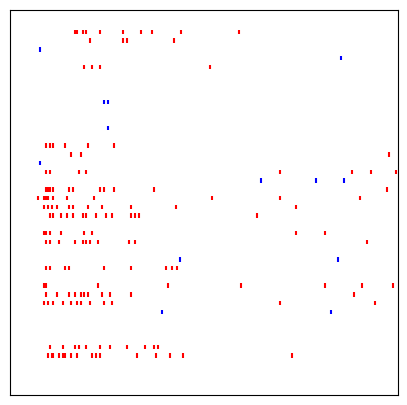

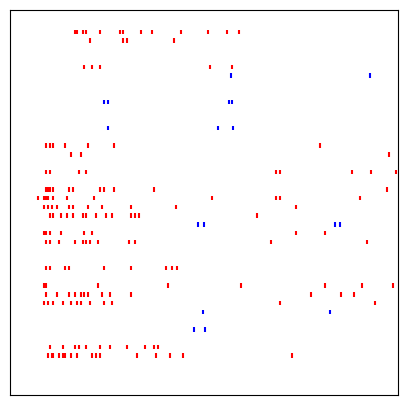

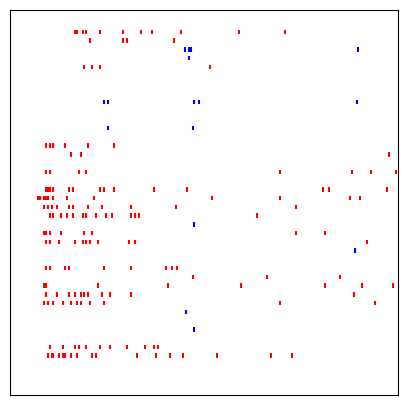

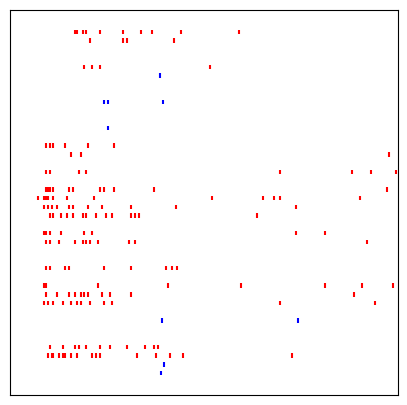

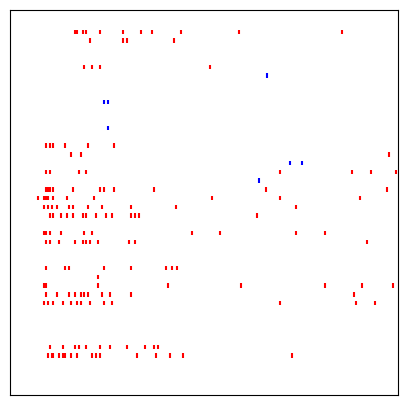

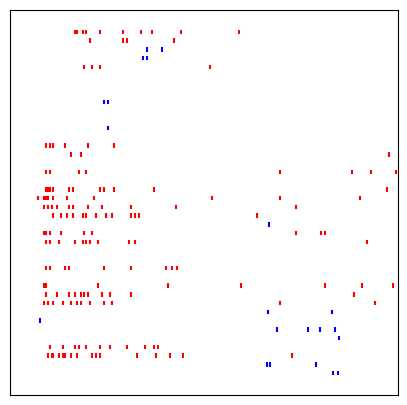

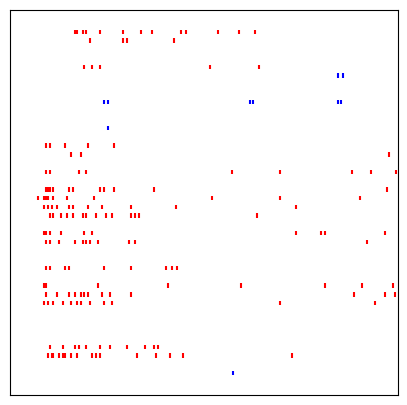

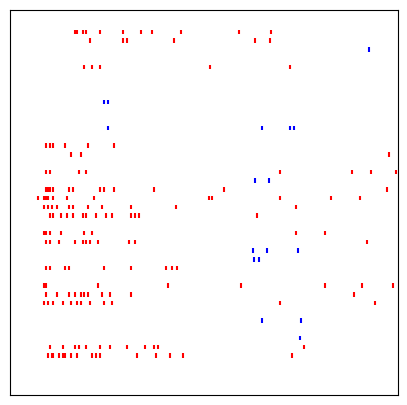

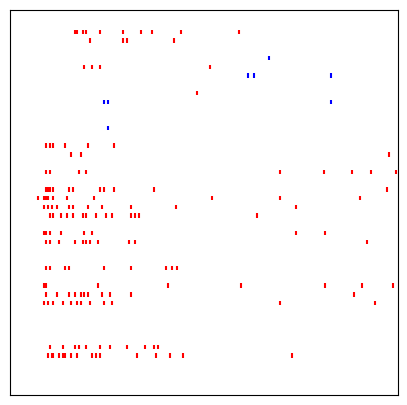

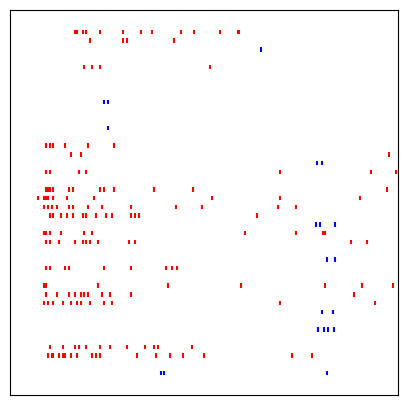

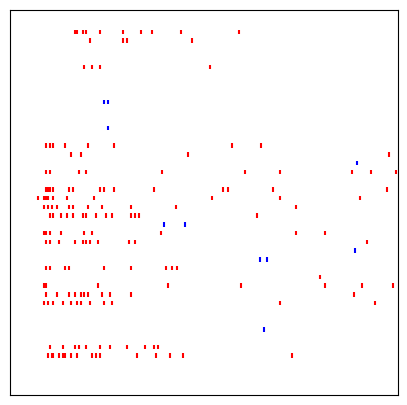

In [69]:
for frame_no, response_no in enumerate(response_indices):

    if frame_no != natural_scene+1:
        continue

    estim_trial = 0

    estim = f"data007/frame_{frame_no}"
    pp_path = os.path.join(pp_base, estim)
    gsort_path = os.path.join(gsort_base, "gsort", estim, wnoise)
    
    path = os.path.join(analysis_base, "estim")

    # Read in .mat file
    ppinfo = loadmat(os.path.join(path,f"preprocessing_info{label}.mat"))
    experiment_boundaries, experiment_names = ppinfo["experimentBoundaries"], ppinfo["experimentNames"]
    # print(f"Experiment boundaries shape {experiment_boundaries.shape}")

    with open(os.path.join(path,f"spike_trains{label}.sef"), "rb") as f:
        sef = np.fromfile(f, dtype=np.int32)
        sef = np.reshape(sef, (int(len(sef)/3), 3), order='F')

    sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

    unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
    unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True) 


    spikes = {}
    probabilities = {}

    initial_spikes = {}
    initial_probabilities = {}


    for t in tqdm(range(unique_times.shape[0])):

        # Set up nested dictionaries
        initial_spikes[t] = {}
        initial_probabilities[t] = {}
        spikes[t] = {}
        probabilities[t] = {}

        # Identify all electrical stimuli delivered simultaneously at time t
        stim = sef_of_interest[np.where(sef_of_interest[:,0] == unique_times[t])[0],1:]

        for s in stim:

            # Find the row of selective_stimuli corresponding to each electrical stimulus
            selective_stimulus = selective_stimuli[np.where((selective_stimuli[:,0] == transform_to_519(s[0])) & (amps_to_indices(selective_stimuli[:,2]) == s[1]))[0][0]]

            # Look for electrical spike sorting results at the time-pattern for each targeted cell (only ever one movie per time-pattern)
            c = int(selective_stimulus[1])

            bs = boolean_spikes(gsort_path, pickle_path_base, c, f"p{t+1}", 0)

            initial_spikes[t][c] = bs
            initial_probabilities[t][c] = np.mean(bs)

            if int(selective_stimulus[3]) and (np.mean(bs) < 0.1): 
                if flip(c, transform_to_519(s[0]), s[1], flip_prob=0.8, plot=False): 
                    bs = [not b for b in bs]

            spikes[t][c] = bs
            probabilities[t][c] = np.mean(bs)


    # Make sure this index agrees with the frame you are looking at
    response = responses[response_no]

    # Align response rasters in time (the very first attempted estim is aligned with the very first rounded recorded vstim spike)
    bin_size_ms = 2.5
    rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

    response_reference_candidates = []
    for c in range(len(rounded_response)):
        if len(rounded_response[c]) > 0:
            response_reference_candidates.append(rounded_response[c][0])
    response_reference = np.min(response_reference_candidates)


    # Sort selective cells of interest by ...
    selective_cells_of_interest_default = np.unique(selective_stimuli[:,1]).astype(int)

    # ... the number of spikes in the response
    # response_counts = np.array([len(cell_spike_times) for cell_spike_times in response])
    # selective_cells_of_interest = selective_cells_of_interest_default[np.argsort(response_counts)]

    # ... STA center ...
    sta_centers = []
    for c in selective_cells_of_interest_default:
            center_x = vcd.get_stafit_for_cell(c).center_x
            # center_y = int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y
            center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
            sta_centers.append([center_x, center_y])
    sta_centers = np.array(sta_centers)

    # ... from bottom to top
    selective_cells_of_interest = selective_cells_of_interest_default[np.argsort(sta_centers[:,1])[::-1]]


    # Make mask to exclude the bad edge cells
    mask = np.isin(selective_cells_of_interest, [6017,2086,62,1877,7098])
    mask = np.logical_not(mask)

    # Make color array for the spike raster plot
    colors = np.array(['blue' if c in on_parasol_cells else 'red' for c in selective_cells_of_interest])


    for et, estim_trial in enumerate(range(15)):

        sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

        unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
        unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True) 


        # Build electrically evoked response for a single trial using the spike dictionary
        estim_response = [[] for _ in range(len(selective_cells_of_interest))]

        for t in range(unique_times.shape[0]):
            for c in spikes[t]:
                if spikes[t][c][estim_trial]:
                    estim_response[np.where(selective_cells_of_interest == c)[0][0]].append(unique_times[t])

        for c in range(len(estim_response)):
            estim_response[c] = np.array(estim_response[c])
        estim_response = np.array(estim_response, dtype=object) / 20 # convert to ms


        estim_response_reference = sef_of_interest[0,0] / 20 # convert to ms

        global_reference = response_reference - ttl_times[response_no]


        espont_vcd = vl.load_vision_data(espont_path,espont,
                                        include_neurons=True)

        espont_spike_times = np.array([espont_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object)

        offset = 20000 # offset of 20000 samples between SEF times and actual data
        low = unique_times[0] + offset
        high = unique_times[-1] + offset
        total_response = np.array([(spike_time[(low < spike_time) & (spike_time < high)] - offset) / 20 for spike_time in espont_spike_times], dtype=object) # convert to ms


        # Get rid of any electrically evoked spikes identified by Vision
        espont_response = [[] for _ in range(len(total_response))]
        for c in range(len(total_response)):
            espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - unique_times/20) >= -1) & ((spike - unique_times/20) <= 2))])
        espont_response = np.array(espont_response, dtype=object)

        fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

        # Create a spike raster plot
        ax.eventplot(estim_response[mask]-estim_response_reference+global_reference, linelengths=0.5, colors=colors[mask])
        ax.eventplot(espont_response[mask]-estim_response_reference+global_reference, linelengths=0.5, colors=colors[mask])

        # Set the y-axis ticks and labels
        ax.set_yticks(range(len(selective_cells_of_interest[mask])), selective_cells_of_interest[mask])
        # ax.set_ylabel('ON and OFF parasols', fontsize=12)

        # Restrict the x axis
        ax.set_xlim(0, 500)

        # Make all ticks larger
        ax.tick_params(axis='both', which='major', labelsize=12)

        # Hide y-axis labels for all plots
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

        # Hide x-axis ticks for all plots
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # Set the x-axis label
        # ax.set_xlabel('Time from Onset (ms)', fontsize=12)

        # Show the plot
        plt.show()

        if estim_trial == 8:
            movie_estim_response = []
            for i in range(len(selective_cells_of_interest)):
                movie_estim_response.append(np.concatenate((estim_response[i], espont_response[i])))
            movie_estim_response = np.array(movie_estim_response, dtype=object)
            movie_estim_response = movie_estim_response[mask]-estim_response_reference+global_reference

## Figure 2A/D: Visual response spike rasters for ON and OFFs

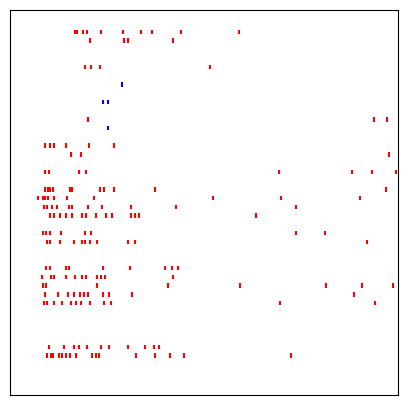

In [70]:
plt.figure(figsize=(5, 5))

# Create a spike raster plot
ordered_response = []
for cell in selective_cells_of_interest:
    idx = np.where(selective_cells_of_interest_default == cell)[0][0]
    ordered_response.append(response[idx])
ordered_response = np.array(ordered_response, dtype=object)

plt.eventplot(ordered_response[mask]-response_reference+global_reference, linelengths=0.5, colors=colors[mask])

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest[mask])), selective_cells_of_interest[mask])
# plt.ylabel('ON and OFF parasols', fontsize=12)

# Set the x-axis label
# plt.xlabel('Time from Onset (ms)', fontsize=12)

# Restrict the x axis
plt.xlim(0, 500)

# Make all ticks larger
plt.tick_params(axis='both', which='major', labelsize=12)

# Hide y-axis ticks
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# Hide x-axis ticks
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Show the plot
plt.show()

movie_vstim_response = ordered_response[mask]-response_reference+global_reference

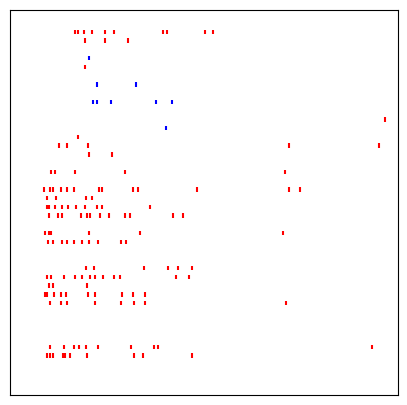

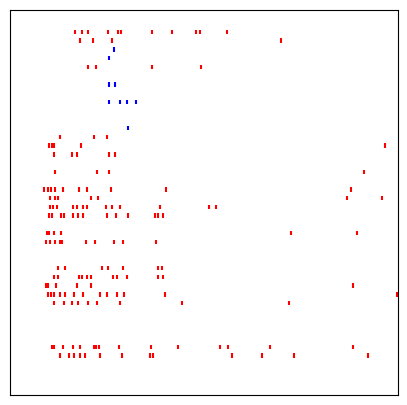

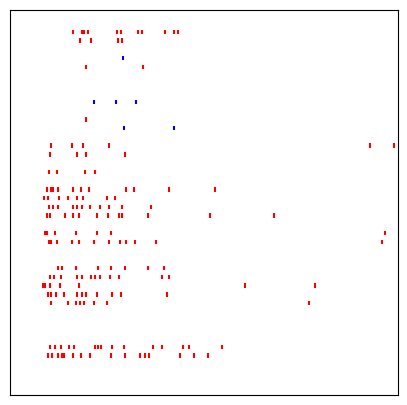

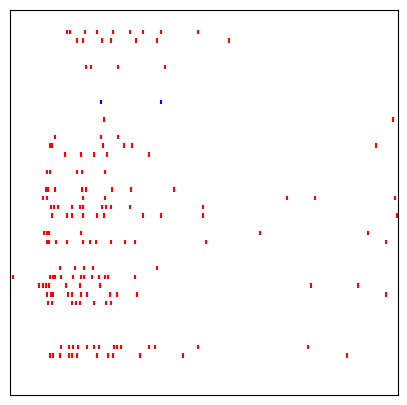

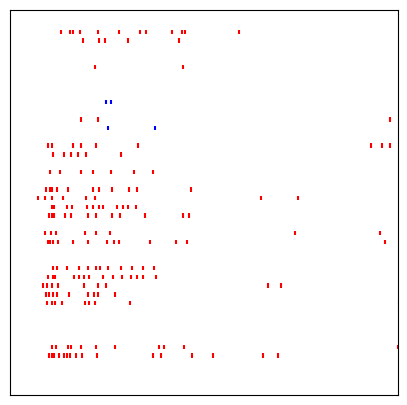

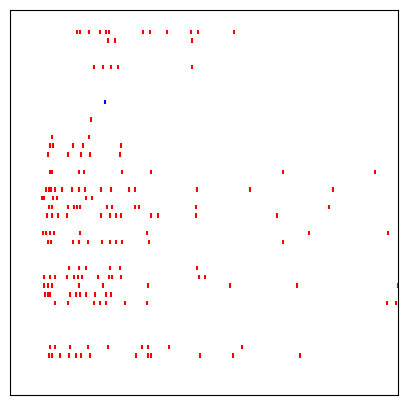

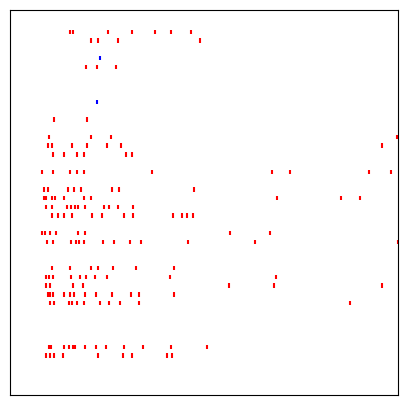

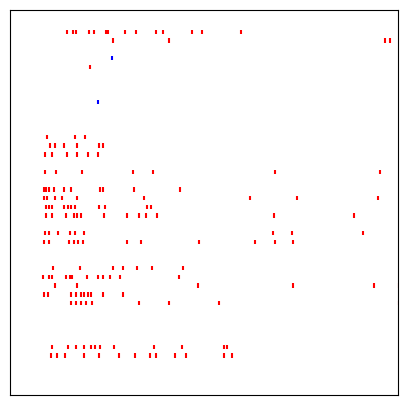

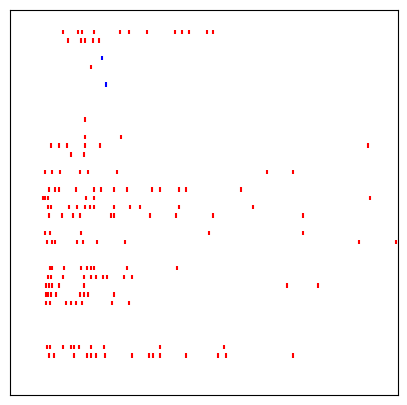

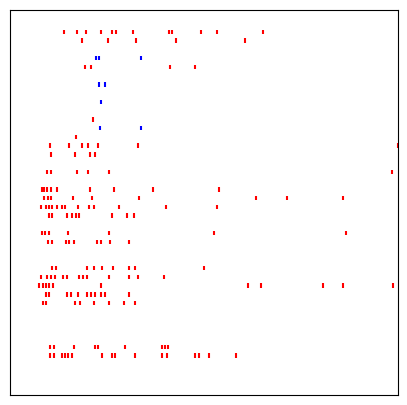

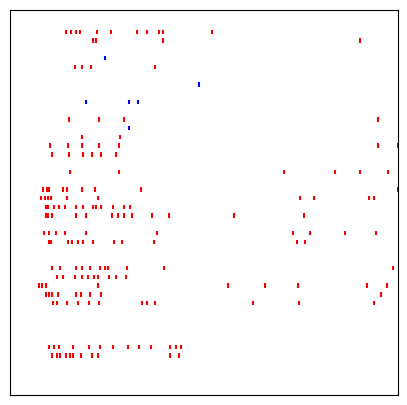

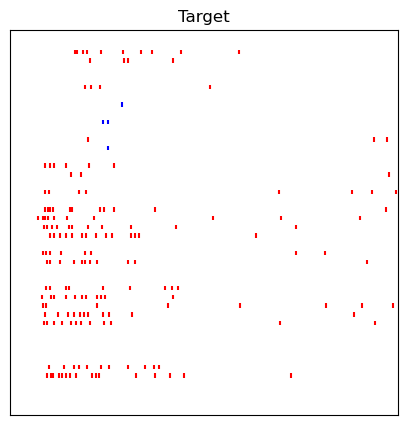

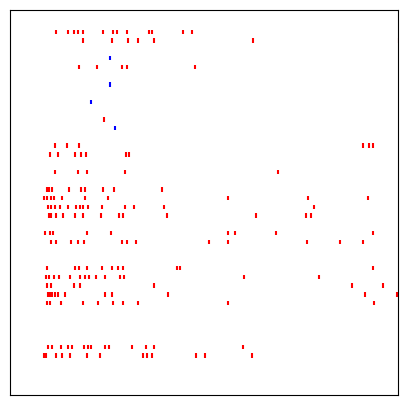

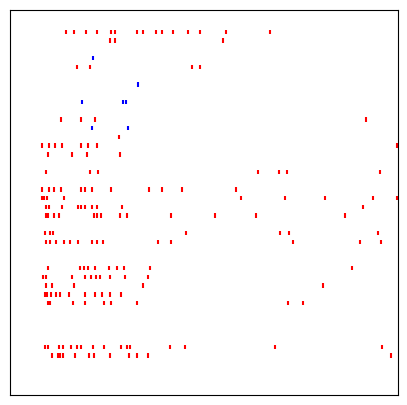

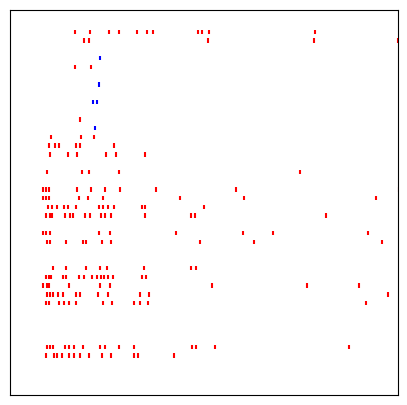

In [71]:
response_no = response_indices[natural_scene+1]
modulo_no = (response_no-30) % 100 # UPDATE ME
select_response_nos = np.arange(modulo_no+30, 1530, 100) # UPDATE ME    

for i, select_response_no in enumerate(select_response_nos):
    response = responses[select_response_no]


    # Align response rasters in time (the very first attempted estim is aligned with the very first rounded recorded vstim spike)
    bin_size_ms = 2.5
    rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

    response_reference_candidates = []
    for c in range(len(rounded_response)):
        if len(rounded_response[c]) > 0:
            response_reference_candidates.append(rounded_response[c][0])
    try:
        response_reference = np.min(response_reference_candidates)
    except:
        print(f"no spikes in response {select_response_no}")
        response_reference = 0

    global_reference = response_reference - ttl_times[select_response_no]


    plt.figure(figsize=(5, 5))

    # Create a spike raster plot
    ordered_response = []
    for cell in selective_cells_of_interest:
        idx = np.where(selective_cells_of_interest_default == cell)[0][0]
        ordered_response.append(response[idx])
    ordered_response = np.array(ordered_response, dtype=object)

    plt.eventplot(ordered_response[mask]-response_reference+global_reference, linelengths=0.5, colors=colors[mask])

    if select_response_no == response_no:
        plt.title(f"Target")

    # Set the y-axis ticks and labels
    plt.yticks(range(len(selective_cells_of_interest[mask])), selective_cells_of_interest[mask])
    # plt.ylabel('ON and OFF parasols', fontsize=12)

    # Set the x-axis label
    # plt.xlabel('Time from Onset (ms)', fontsize=12)

    # Restrict the x axis
    plt.xlim(0, 500)

    # Make all ticks larger
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Hide y-axis ticks
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    # Hide x-axis ticks
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Show the plot
    plt.show()

## Bonus: Visual and electrical ON and OFF activity movies

In [72]:
def animate_raster(spikes,cells):

    ons = vcd.get_all_cells_similar_to_type('ON parasol')
    offs = vcd.get_all_cells_similar_to_type('OFF parasol')
    rfs = []

    # Make figure
    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(3,3))

    def init():

        # Set axis properties
        ax.set_xlim(0+275, 640-1-260)
        ax.set_ylim(0+125, 320-1-80)
        ax.set_aspect('equal')
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        ax.set_frame_on(False)
        ax.invert_yaxis()

        # Draw RF boundaries for each cell
        assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
        STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

        for c in cells:

            center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
            # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
            center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
            std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
            std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
            rot = vcd.get_stafit_for_cell(c).rot

            rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2, alpha=0.5)

            if c in ons:
                rf.set_edgecolor('blue')
            elif c in offs:
                rf.set_edgecolor('red')        
                
            ax.add_patch(rf)
            rfs.append(rf)

        return rfs


    # Update function
    def update(frame):

        frame = frame * 1

        # Find which cells have spiked within the past X ms of this frame
        cells_spiking = [True if np.any((frame - spikes[i] >= 0) & (frame - spikes[i] < 5)) else False for i in range(len(cells))]

        # Update RF fill
        for i in range(len(cells)):

            rf = rfs[i]
            c = cells[i]

            if cells_spiking[i]:
                rf.set_fill(True)
                if c in ons:
                    rf.set_facecolor('blue')
                elif c in offs:
                    rf.set_facecolor('red')

            else:
                rf.set_fill(False)

        return rfs
                

    # Create the animation
    num_frames = int(250/1)
    ani = animation.FuncAnimation(fig, update, init_func=init, frames=range(num_frames), interval=20, blit=True)
    plt.close()

    return ani

In [73]:
# Make animation
ani = animate_raster(movie_vstim_response, selective_cells_of_interest[mask])

# Display animation
HTML(ani.to_jshtml())

# Save animation as GIF
writer = animation.PillowWriter(fps=20)
ani.save('/Volumes/Lab/Users/ajphillips/iko/tmp/movies/vstim_77.gif', writer=writer)

In [74]:
# Make animation
ani = animate_raster(movie_estim_response, selective_cells_of_interest[mask])

# Display animation
HTML(ani.to_jshtml())

# Save animation as GIF
writer = animation.PillowWriter(fps=20)
ani.save('/Volumes/Lab/Users/ajphillips/iko/tmp/movies/estim_77.gif', writer=writer)

## Figure 3A-C: All visual and electrical trials for select ON and OFF

In [247]:
natural_scene = 76

frame_no = natural_scene+1
vstim_trial = (response_indices[frame_no] - 30) // 100

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)

In [248]:
vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
for i in range(vstim_responses.shape[0]):
    if len(vstim_responses[i]) == 0:
        for j in range(len(selective_cells_of_interest)):
            vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1300.0*ms)
    else:
        for j in range(len(selective_cells_of_interest)):
            vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1300.0*ms)

estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
for i in range(estim_espont_responses.shape[0]):
    if len(estim_espont_responses[i]) == 0:
        for j in range(len(selective_cells_of_interest)):
            estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1300.0*ms)
    else:
        for j in range(len(selective_cells_of_interest)):
            estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1300.0*ms)

In [249]:
print(vstim_responses.shape)
print(estim_espont_responses.shape)

(15, 45)
(15, 45)


In [250]:
q = 1. / (25. * ms) # q=0 means no cost for any shift of spikes, q=np.inf means infinite cost for any spike shift and hence exclusion of spike shifts

vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
for i in tqdm(range(vstim_spike_trains.shape[1])):

    spike_train_list = []
    for j in range(vstim_spike_trains.shape[0]):
        spike_train_list.append(vstim_spike_trains[j,i])

    vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
for i in tqdm(range(estim_espont_spike_trains.shape[1])):

    spike_train_list = []
    spike_train_list.append(vstim_spike_trains[vstim_trial,i])
    for j in range(estim_espont_spike_trains.shape[0]):
        spike_train_list.append(estim_espont_spike_trains[j,i])

    estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

  0%|          | 0/45 [00:00<?, ?it/s]

100%|██████████| 45/45 [00:09<00:00,  4.64it/s]


In [251]:
print(vstim_vp_distance.shape)
print(estim_espont_vp_distance.shape)

(45, 15, 15)
(45, 16, 16)


In [253]:
# Make mask to exclude the bad edge cells
mask = np.isin(selective_cells_of_interest, [6017,2086,62,1877,7098])
mask = np.logical_not(mask)

In [ ]:
for c in range(len(selective_cells_of_interest)):

    if not mask[c]:
        continue

    this_cell = selective_cells_of_interest[c]
    if this_cell in on_parasol_cells:
        color = 'blue'
    elif this_cell in off_parasol_cells:
        color = 'red'
    else:
        raise ValueError(f"Cell {this_cell} should not be included")
    
    # Plot the visually evoked spike train and all of the electrically evoked spike trains on the same plot for cell c
    plt.figure(figsize=(5, 5))

    # Create a spike raster plot
    cell_responses = []
    for i in range(vstim_responses.shape[0]):
        cell_responses.append(vstim_responses[i,c])
    plt.eventplot(cell_responses, linelengths=0.5, colors=[color if i == vstim_trial else 'k' for i in range(vstim_responses.shape[0])])

    # Set the y-axis ticks and labels
    plt.yticks(range(vstim_responses.shape[0]), [f'Visual {i}' for i in range(vstim_responses.shape[0])])
    # plt.ylabel('Trials', fontsize=12)

    # Set the x-axis label
    # plt.xlabel('Time from Onset (ms)', fontsize=12)
    plt.xlim(0, 500)

    # Set the plot title
    # plt.title(f"Cell {selective_cells_of_interest[c]}")

    # Make all ticks larger
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Hide y-axis ticks
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    # Hide x-axis ticks
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Show the plot
    plt.show()


    # Plot the visually evoked spike train and all of the electrically evoked spike trains on the same plot for cell c
    plt.figure(figsize=(5, 5))

    # Create a spike raster plot
    cell_responses = []
    for i in range(estim_espont_responses.shape[0]):
        cell_responses.append(estim_espont_responses[i,c])
    plt.eventplot(cell_responses, linelengths=0.5, colors=color)

    # Set the y-axis ticks and labels
    plt.yticks(range(estim_espont_responses.shape[0]), [f'Estim Espont {i}' for i in range(estim_espont_responses.shape[0])])
    # plt.ylabel('Trials', fontsize=12)

    # Set the x-axis label
    plt.xlabel('Time from Onset (ms)', fontsize=12)
    plt.xlim(0, 500)

    # Set the plot title
    # plt.title(f"Cell {selective_cells_of_interest[c]}")

    # Make all ticks larger
    plt.tick_params(axis='both', which='major', labelsize=12)

    # Hide y-axis ticks
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    # Show the plot
    plt.show()


    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))

    window_buffer = 200
    window_size = 150

    assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
    STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

    for c in np.concatenate((on_parasol_cells, off_parasol_cells)):

        center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
        # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
        center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
        std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
        std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
        rot = vcd.get_stafit_for_cell(c).rot

        rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

        if c == this_cell:
            # rf.set_edgecolor('red')
            rf.set_fill(True)
            rf.set_facecolor(color)
            rf.set_alpha(0.5)
        else:
            # rf.set_edgecolor('gray')
            rf.set_fill(True)
            rf.set_facecolor('gray')
            rf.set_alpha(0.5)
        
        # Skip adding patch if RF center is farther than threshold from closest_on_parasol_cell RF center
        if np.sqrt((center_x - STIXEL * vcd.get_stafit_for_cell(closest_on_parasol_cell).center_x)**2 + 
                (center_y - STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(closest_on_parasol_cell).center_y))**2) > window_buffer:
            continue
        ax.add_patch(rf)

    ax.set_xlim(0+250, 640-1-225)
    ax.set_ylim(0+100, 320-1-50)
    # ax.set_xlim(0+250, 640-1-200)
    # ax.set_ylim(0+75, 320-1-50)
    # ax.set_xlim(0+225, 640-1-225)
    # ax.set_ylim(0+75, 320-1-75)
    ax.set_aspect('equal')
    # ax.set_title(cell_type)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_frame_on(False)
    ax.invert_yaxis()
    plt.show()

    print(f"Cell {this_cell}")

## Figure 3D-F: Victor-Purpura distance comparison by cell

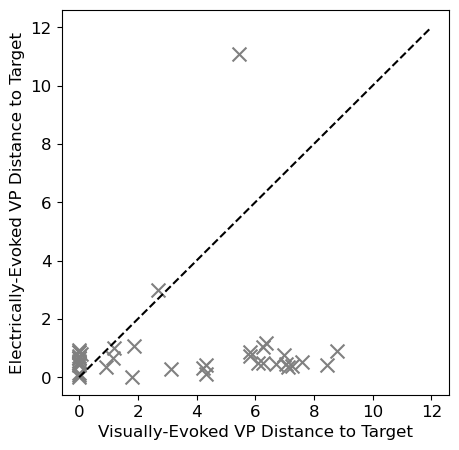

In [254]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

featured_cells = [] # [1097,965,7698,2762,3381,3618]

for c in range(len(selective_cells_of_interest)):

    if not mask[c]:
        continue

    color = 'gray'

    vstim_vp = vstim_vp_distance[c,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
    estim_espont_vp = estim_espont_vp_distance[c,0,1:15]

    plt.scatter(np.mean(vstim_vp), np.mean(estim_espont_vp), color=color, marker='x', s=100)

for c in range(len(selective_cells_of_interest)):

    this_cell = selective_cells_of_interest[c]
    if this_cell not in featured_cells:
        continue

    if this_cell in on_parasol_cells:
        color = 'blue'
    elif this_cell in off_parasol_cells:
        color = 'red'
    else:
        raise ValueError(f"Cell {this_cell} should not be included")

    vstim_vp = vstim_vp_distance[c,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
    estim_espont_vp = estim_espont_vp_distance[c,0,1:15]

    plt.scatter(np.mean(vstim_vp), np.mean(estim_espont_vp), color=color, marker='X', s=200)
    
    # Add the cell number next to its point
    # plt.text(np.mean(vstim_vp), np.mean(estim_espont_vp), this_cell, fontsize=12)

# Set the labels and title
ax.set_xlabel('Visually-Evoked VP Distance to Target', fontsize=12)
ax.set_ylabel('Electrically-Evoked VP Distance to Target', fontsize=12)

# Make all ticks larger
ax.tick_params(axis='both', which='major', labelsize=12)

# Make a x=y line
x = np.linspace(0, 12, 12)
ax.plot(x, x, color='k', linestyle='--')

# Show the plot
plt.show()

## Figure 4: Multi-neuron Victor-Purpura distance comparison by visual stimulus

In [255]:
def multiprocess_vp(frame_no):

    vstim_trial = (response_indices[frame_no] - 30) // 100

    vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
    estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

    vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
    for i in range(vstim_responses.shape[0]):
        if len(vstim_responses[i]) == 0:
            for j in range(len(selective_cells_of_interest)):
                vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1300.0*ms)
        else:
            for j in range(len(selective_cells_of_interest)):
                vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1300.0*ms)

    estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
    for i in range(estim_espont_responses.shape[0]):
        if len(estim_espont_responses[i]) == 0:
            for j in range(len(selective_cells_of_interest)):
                estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1300.0*ms)
        else:
            for j in range(len(selective_cells_of_interest)):
                estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1300.0*ms)


    q = 1. / (25 * ms) # q=0 means no cost for any shift of spikes, q=np.inf means infinite cost for any spike shift and hence exclusion of spike shifts

    vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
    for i in range(vstim_spike_trains.shape[1]):

        spike_train_list = []
        for j in range(vstim_spike_trains.shape[0]):
            spike_train_list.append(vstim_spike_trains[j,i])

        vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

    estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
    for i in range(estim_espont_spike_trains.shape[1]):

        spike_train_list = []
        spike_count = 0
        spike_train_list.append(vstim_spike_trains[vstim_trial,i])
        for j in range(estim_espont_spike_trains.shape[0]):
            spike_train_list.append(estim_espont_spike_trains[j,i])
            spike_count += len(estim_espont_spike_trains[j,i].times)
        spike_count /= estim_espont_spike_trains.shape[0]
        if spike_count == 0:
            spike_count = np.inf

        estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q) # / spike_count


    return vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]], estim_espont_vp_distance[:,0,1:]


frame_nos = np.arange(1,101)

vstim_vp_distances = np.empty((len(frame_nos), len(selective_cells_of_interest), vstim_responses.shape[0]-1))
estim_espont_vp_distances = np.empty((len(frame_nos), len(selective_cells_of_interest), estim_espont_responses.shape[0]))

with Pool(36) as p:
    results = list(tqdm(p.imap(multiprocess_vp, frame_nos), total=len(frame_nos)))

    for i in range(len(results)):
        vstim_vp_distances[i] = results[i][0]
        estim_espont_vp_distances[i] = results[i][1]

100%|██████████| 100/100 [01:16<00:00,  1.31it/s]


In [256]:
print(vstim_vp_distances.shape)
print(estim_espont_vp_distances.shape)

(100, 45, 14)
(100, 45, 15)


In [257]:
cell_vp_distances = np.zeros(len(selective_cells_of_interest))

for s in range(estim_espont_vp_distances.shape[0]):
    for c in range(estim_espont_vp_distances.shape[1]):
        cell_vp_distances[c] += np.mean(estim_espont_vp_distances[s,c,:-1])

cell_vp_distances /= estim_espont_vp_distances.shape[0]

thresh = 1
error_cells = []
for c in range(len(selective_cells_of_interest)):

    if not mask[c]:
        continue

    print(f"Cell {selective_cells_of_interest[c]} error: {cell_vp_distances[c]}/spike")

    if cell_vp_distances[c] > thresh:
        error_cells.append(selective_cells_of_interest[c])

print(f"{100*np.mean(cell_vp_distances[mask] < thresh)}% of cells were reliably encoded")

Cell 333 error: 0.5215757142856267/spike
Cell 632 error: 0.49403285714279993/spike
Cell 661 error: 0.5485471428572012/spike
Cell 965 error: 0.9428157142856946/spike
Cell 1097 error: 0.8829871428571018/spike
Cell 1248 error: 1.2986428571426567/spike
Cell 1579 error: 1.1749814285714102/spike
Cell 1592 error: 0.8396571428569115/spike
Cell 1697 error: 0.2614657142856101/spike
Cell 1715 error: 0.37530142857158866/spike
Cell 2091 error: 0.7465171428571992/spike
Cell 2270 error: 0.8309071428571635/spike
Cell 2404 error: 0.9640000000001372/spike
Cell 2478 error: 1.1756328571426975/spike
Cell 2734 error: 0.7786771428570066/spike
Cell 2762 error: 0.9328342857144201/spike
Cell 2853 error: 1.141532857142847/spike
Cell 3154 error: 0.5966557142857185/spike
Cell 3332 error: 0.7026428571429112/spike
Cell 3381 error: 0.7466057142856042/spike
Cell 3618 error: 0.8106985714285503/spike
Cell 4038 error: 0.6094585714285636/spike
Cell 4081 error: 1.2228242857142932/spike
Cell 4143 error: 4.334374285714265/sp

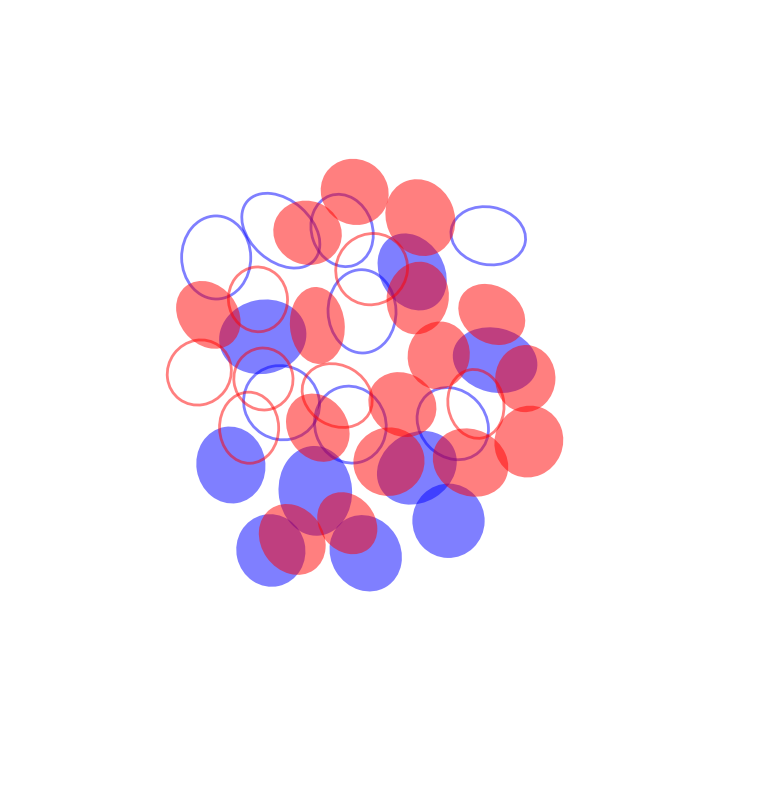

In [258]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))

assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

for c in np.concatenate((on_parasol_cells, off_parasol_cells)):

    center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
    # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
    center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
    std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
    std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
    rot = vcd.get_stafit_for_cell(c).rot

    rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

    if c in error_cells:
        rf.set_fill(False)
        rf.set_alpha(0.5)
        if c in on_parasol_cells:
            rf.set_edgecolor('blue')
        elif c in off_parasol_cells:
            rf.set_edgecolor('red')
    elif c in on_parasol_cells:
        rf.set_fill(True)
        rf.set_facecolor('blue')
        rf.set_alpha(0.5)
    elif c in off_parasol_cells:     
        rf.set_fill(True)
        rf.set_facecolor('red')
        rf.set_alpha(0.5)
    
    ax.add_patch(rf)

# ax.set_xlim(0+250, 640-1-225)
# ax.set_ylim(0+100, 320-1-50)
# ax.set_xlim(0+250, 640-1-200)
# ax.set_ylim(0+75, 320-1-50)
# ax.set_xlim(0+225, 640-1-225)
# ax.set_ylim(0+75, 320-1-75)
ax.set_xlim(0+250, 640-1-225)
ax.set_ylim(0+100, 320-1-50)
ax.set_aspect('equal')
# ax.set_title(cell_type)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

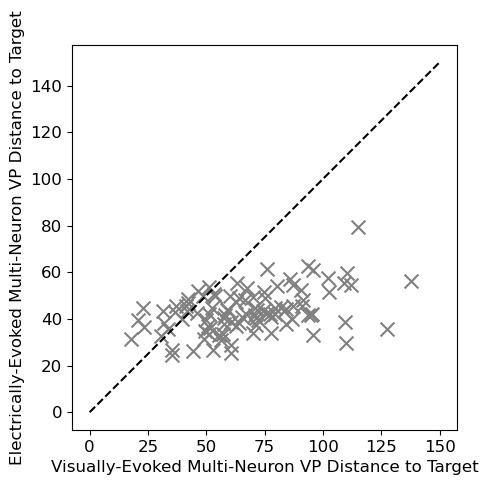

In [259]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

temp = [False if s in [34,51,76] else True for s in range(vstim_vp_distances.shape[0])]

total_vstim_vp_distances = np.sum(vstim_vp_distances[:,mask,:], axis=1)
# total_estim_espont_vp_distances = estim_espont_vp_distances[:,:,:-1]
# total_estim_espont_vp_distances = np.sum(total_estim_espont_vp_distances[:,mask,:], axis=1)
total_estim_espont_vp_distances = np.sum(estim_espont_vp_distances[:,mask,:], axis=1)
average_total_vstim_vp_distances = np.mean(total_vstim_vp_distances, axis=1)
average_total_estim_espont_vp_distances = np.mean(total_estim_espont_vp_distances, axis=1)

ax.scatter(average_total_vstim_vp_distances, average_total_estim_espont_vp_distances, color='gray', marker='x', s=100)
# ax.scatter(average_total_vstim_vp_distances[temp], average_total_estim_espont_vp_distances[temp], color='gray', marker='x', s=100)
# for s in [34,51,76]:
#     ax.scatter(average_total_vstim_vp_distances[s], average_total_estim_espont_vp_distances[s], color='k', marker='X', s=200)
# ax.scatter(np.mean(average_total_vstim_vp_distances), np.mean(average_total_estim_espont_vp_distances), color='k', marker='D', s=100)

# Set the labels and title
ax.set_xlabel('Visually-Evoked Multi-Neuron VP Distance to Target', fontsize=12)
ax.set_ylabel('Electrically-Evoked Multi-Neuron VP Distance to Target', fontsize=12)

# Make all ticks larger
ax.tick_params(axis='both', which='major', labelsize=12)

# Make a x=y line
x = np.linspace(0, 150, 150)
ax.plot(x, x, color='k', linestyle='--')

ax.set_aspect('equal')

# Show the plot
plt.show()

## Figure 5: Arbitrary control over ON and OFFs
Use *post_analysis_text.ipynb*